In [2]:
import pandas as pd
df1 = pd.read_excel("online_retail_II.xlsx", sheet_name="Year 2009-2010")

In [3]:
df2 = pd.read_excel("online_retail_II.xlsx", sheet_name="Year 2010-2011")

In [4]:
df2.info()

<class 'pandas.DataFrame'>
RangeIndex: 541910 entries, 0 to 541909
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   Invoice      541910 non-null  object        
 1   StockCode    541910 non-null  object        
 2   Description  540456 non-null  object        
 3   Quantity     541910 non-null  int64         
 4   InvoiceDate  541910 non-null  datetime64[us]
 5   Price        541910 non-null  float64       
 6   Customer ID  406830 non-null  float64       
 7   Country      541910 non-null  str           
dtypes: datetime64[us](1), float64(2), int64(1), object(3), str(1)
memory usage: 33.1+ MB


In [5]:
df = pd.concat([df2,df1],axis=0,ignore_index=True)

In [6]:
df.columns

Index(['Invoice', 'StockCode', 'Description', 'Quantity', 'InvoiceDate',
       'Price', 'Customer ID', 'Country'],
      dtype='str')

In [7]:
df.head(10)

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
5,536365,22752,SET 7 BABUSHKA NESTING BOXES,2,2010-12-01 08:26:00,7.65,17850.0,United Kingdom
6,536365,21730,GLASS STAR FROSTED T-LIGHT HOLDER,6,2010-12-01 08:26:00,4.25,17850.0,United Kingdom
7,536366,22633,HAND WARMER UNION JACK,6,2010-12-01 08:28:00,1.85,17850.0,United Kingdom
8,536366,22632,HAND WARMER RED POLKA DOT,6,2010-12-01 08:28:00,1.85,17850.0,United Kingdom
9,536368,22960,JAM MAKING SET WITH JARS,6,2010-12-01 08:34:00,4.25,13047.0,United Kingdom


In [8]:
df.shape

(1067371, 8)

In [9]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1067371 entries, 0 to 1067370
Data columns (total 8 columns):
 #   Column       Non-Null Count    Dtype         
---  ------       --------------    -----         
 0   Invoice      1067371 non-null  object        
 1   StockCode    1067371 non-null  object        
 2   Description  1062989 non-null  object        
 3   Quantity     1067371 non-null  int64         
 4   InvoiceDate  1067371 non-null  datetime64[us]
 5   Price        1067371 non-null  float64       
 6   Customer ID  824364 non-null   float64       
 7   Country      1067371 non-null  str           
dtypes: datetime64[us](1), float64(2), int64(1), object(3), str(1)
memory usage: 65.1+ MB


In [10]:
df = df.dropna(subset="Customer ID")

In [11]:
df.info()

<class 'pandas.DataFrame'>
Index: 824364 entries, 0 to 1067370
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   Invoice      824364 non-null  object        
 1   StockCode    824364 non-null  object        
 2   Description  824364 non-null  object        
 3   Quantity     824364 non-null  int64         
 4   InvoiceDate  824364 non-null  datetime64[us]
 5   Price        824364 non-null  float64       
 6   Customer ID  824364 non-null  float64       
 7   Country      824364 non-null  str           
dtypes: datetime64[us](1), float64(2), int64(1), object(3), str(1)
memory usage: 56.6+ MB


In [12]:
df= df[~df["Invoice"].astype("str").str.startswith("C")]

In [13]:
df.info()

<class 'pandas.DataFrame'>
Index: 805620 entries, 0 to 1067370
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   Invoice      805620 non-null  object        
 1   StockCode    805620 non-null  object        
 2   Description  805620 non-null  object        
 3   Quantity     805620 non-null  int64         
 4   InvoiceDate  805620 non-null  datetime64[us]
 5   Price        805620 non-null  float64       
 6   Customer ID  805620 non-null  float64       
 7   Country      805620 non-null  str           
dtypes: datetime64[us](1), float64(2), int64(1), object(3), str(1)
memory usage: 55.3+ MB


In [14]:
824364 - 805620

18744

In [15]:
df[df["Quantity"]>0].shape

(805620, 8)

In [16]:
df["Revenue"] = df["Quantity"] * df["Price"]

In [17]:
df["InvoiceDate"] = pd.to_datetime(df["InvoiceDate"])
df["Month"] = df["InvoiceDate"].dt.to_period('M').astype("str")


In [18]:
df.head(5)

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country,Revenue,Month
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom,15.30,2010-12
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34,2010-12
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom,22.00,2010-12
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34,2010-12
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34,2010-12


In [19]:
import matplotlib.pyplot as plt

In [20]:
monthly_revenue = df.groupby("Month").agg(monthly_revenue = ("Revenue", "sum")).reset_index()

In [21]:
monthly_revenue.head()


,Month,monthly_revenue
0,2009-12,686654.160
1,2010-01,557319.062
2,2010-02,506371.066
3,2010-03,699608.991
4,2010-04,594609.192


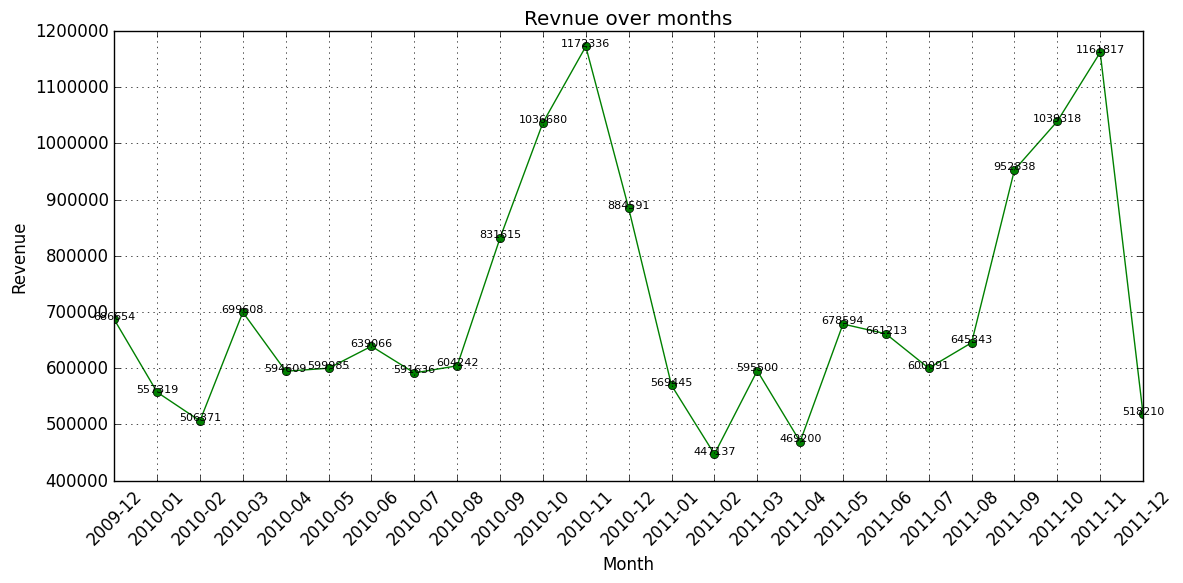

In [22]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,6))
plt.style.use("classic")
plt.plot(monthly_revenue["Month"], monthly_revenue["monthly_revenue"], marker = "o", color = "green")
plt.xlabel("Month")
plt.ylabel("Revenue")
plt.title("Revnue over months")
plt.xticks(rotation = 45)
plt.grid(True)
plt.tight_layout(h_pad=1, w_pad=1)
for i in range(len(monthly_revenue.values)):
    plt.text(monthly_revenue.loc[i,"Month"], monthly_revenue.loc[i, "monthly_revenue"]+1000,f"{int(monthly_revenue.loc[i, "monthly_revenue"])}", ha = "center", fontsize = 8)
    
    

plt.show()

In [23]:
df.head(2)

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country,Revenue,Month
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom,15.30,2010-12
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34,2010-12


In [24]:
country_revenue = df.groupby("Country")["Revenue"].sum().sort_values(ascending=False).head(10)

In [25]:
country_revenue

Country
United Kingdom    1.472315e+07
EIRE              6.216311e+05
Netherlands       5.542323e+05
Germany           4.312625e+05
France            3.552575e+05
Australia         1.699681e+05
Spain             1.091785e+05
Switzerland       1.003653e+05
Sweden            9.154972e+04
Denmark           6.986219e+04
Name: Revenue, dtype: float64

Text(0.5, 1.0, 'Countries by revenue')

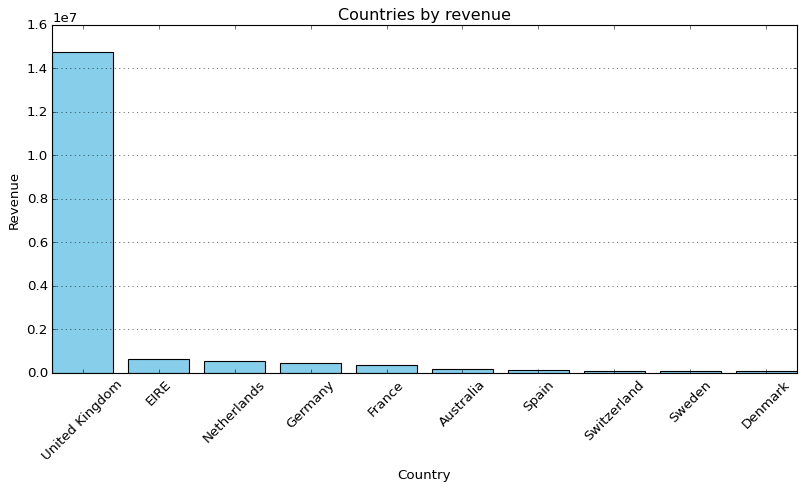

In [26]:
plt.style.use('seaborn-v0_8')
plt.figure(figsize=(10,6))
plt.style.use('classic')
plt.bar(country_revenue.index, country_revenue.values, color = "skyblue")
plt.xticks(rotation = 45)
plt.tight_layout()
plt.grid(axis="y")
plt.xlabel("Country")
plt.ylabel("Revenue")
plt.title("Countries by revenue")

In [27]:

df.info()

<class 'pandas.DataFrame'>
Index: 805620 entries, 0 to 1067370
Data columns (total 10 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   Invoice      805620 non-null  object        
 1   StockCode    805620 non-null  object        
 2   Description  805620 non-null  object        
 3   Quantity     805620 non-null  int64         
 4   InvoiceDate  805620 non-null  datetime64[us]
 5   Price        805620 non-null  float64       
 6   Customer ID  805620 non-null  float64       
 7   Country      805620 non-null  str           
 8   Revenue      805620 non-null  float64       
 9   Month        805620 non-null  str           
dtypes: datetime64[us](1), float64(3), int64(1), object(3), str(2)
memory usage: 67.6+ MB


In [28]:
sample_df = df.sample(1000,random_state=1)

In [29]:
sample_df.head(1)

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country,Revenue,Month
353055,567720,C2,CARRIAGE,1,2011-09-22 10:37:00,50.0,14911.0,EIRE,50.0,2011-09


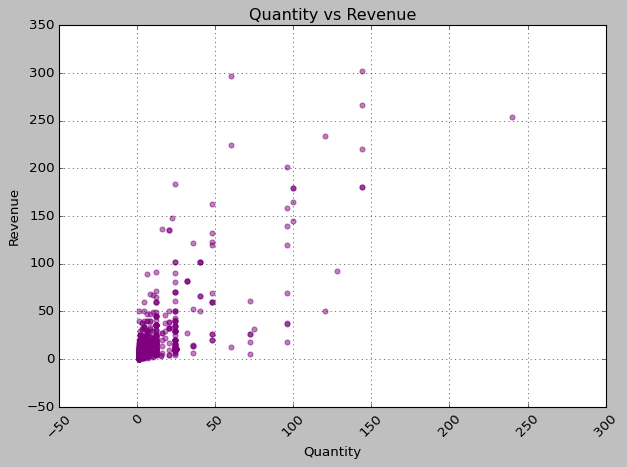

In [30]:
plt.Figure(figsize=(12,6))

plt.scatter(sample_df["Quantity"], sample_df["Revenue"], alpha=0.5, color = "purple")
plt.xlabel("Quantity")
plt.ylabel("Revenue")
plt.title("Quantity vs Revenue")
plt.xticks(rotation = 45)
plt.grid(True)
plt.tight_layout()
plt.show()

In [31]:
df.head(2)

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country,Revenue,Month
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom,15.30,2010-12
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34,2010-12


In [32]:
monthly_quantity = df.groupby("Month")["Quantity"].sum().sort_index()

In [33]:
monthly_revenue = df.groupby("Month")["Revenue"].sum().sort_index()

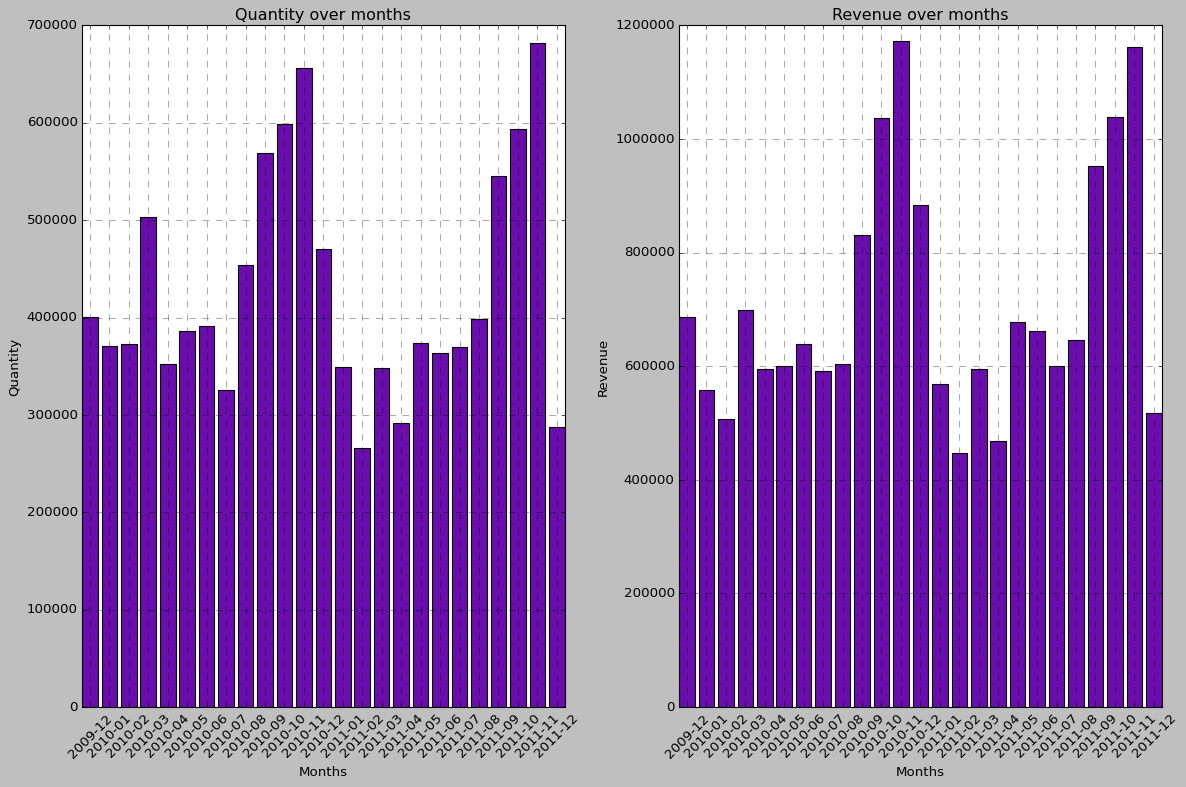

In [34]:
plt.figure(figsize=(15,10))

plt.subplot(1,2,1)
plt.bar(monthly_quantity.index, monthly_quantity.values, color = "#6A0DAD")
plt.xlabel("Months", fontsize = 12)
plt.xticks(rotation = 45)
plt.ylabel("Quantity", fontsize = 12)
plt.title("Quantity over months")
plt.grid(True, linestyle = "--", alpha = 0.6)


plt.subplot(1,2,2)
plt.bar(monthly_revenue.index, monthly_revenue.values, color = "#6A0DAD")
plt.xlabel("Months", fontsize = 12)
plt.xticks(rotation = 45)
plt.ylabel("Revenue", fontsize = 12)
plt.title("Revenue over months")
plt.grid(True, linestyle = "--", alpha = 0.6)

plt.tight_layout()
plt.show()


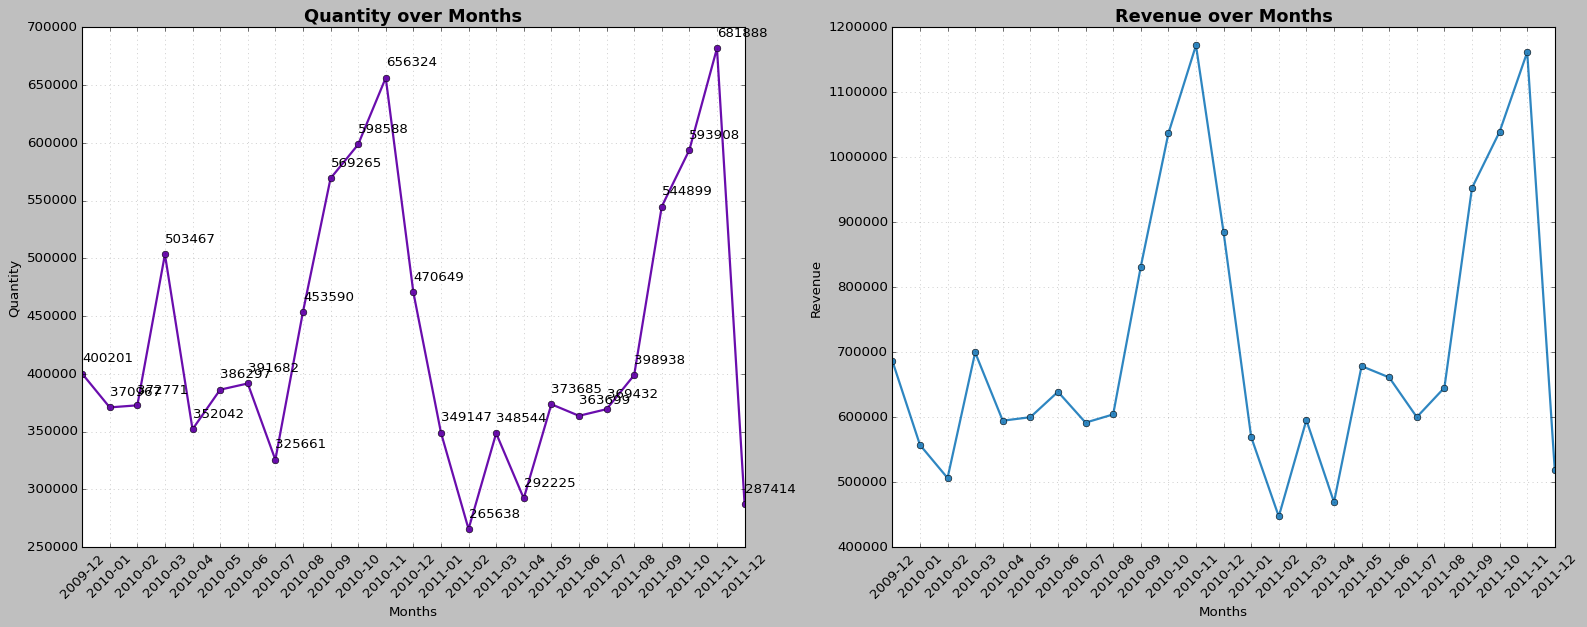

In [35]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(1,2, figsize=(20,8))

# Quantity plot
ax[0].plot(monthly_quantity.index, monthly_quantity.values,
           marker='o', linewidth=2, color='#6A0DAD')

ax[0].set_title("Quantity over Months", fontsize=16, fontweight='bold')
ax[0].set_xlabel("Months")
ax[0].set_ylabel("Quantity")
ax[0].tick_params(axis='x', rotation=45)
ax[0].grid(alpha=0.3)
for i in range(len(monthly_quantity.index)):
    ax[0].text(monthly_quantity.index[i], monthly_quantity.values[i]+10000, f"{monthly_quantity.values[i]}")

# Revenue plot
ax[1].plot(monthly_revenue.index, monthly_revenue.values,
           marker='o', linewidth=2, color='#2E86C1')

ax[1].set_title("Revenue over Months", fontsize=16, fontweight='bold')
ax[1].set_xlabel("Months")
ax[1].set_ylabel("Revenue")
ax[1].tick_params(axis='x', rotation=45)
ax[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()


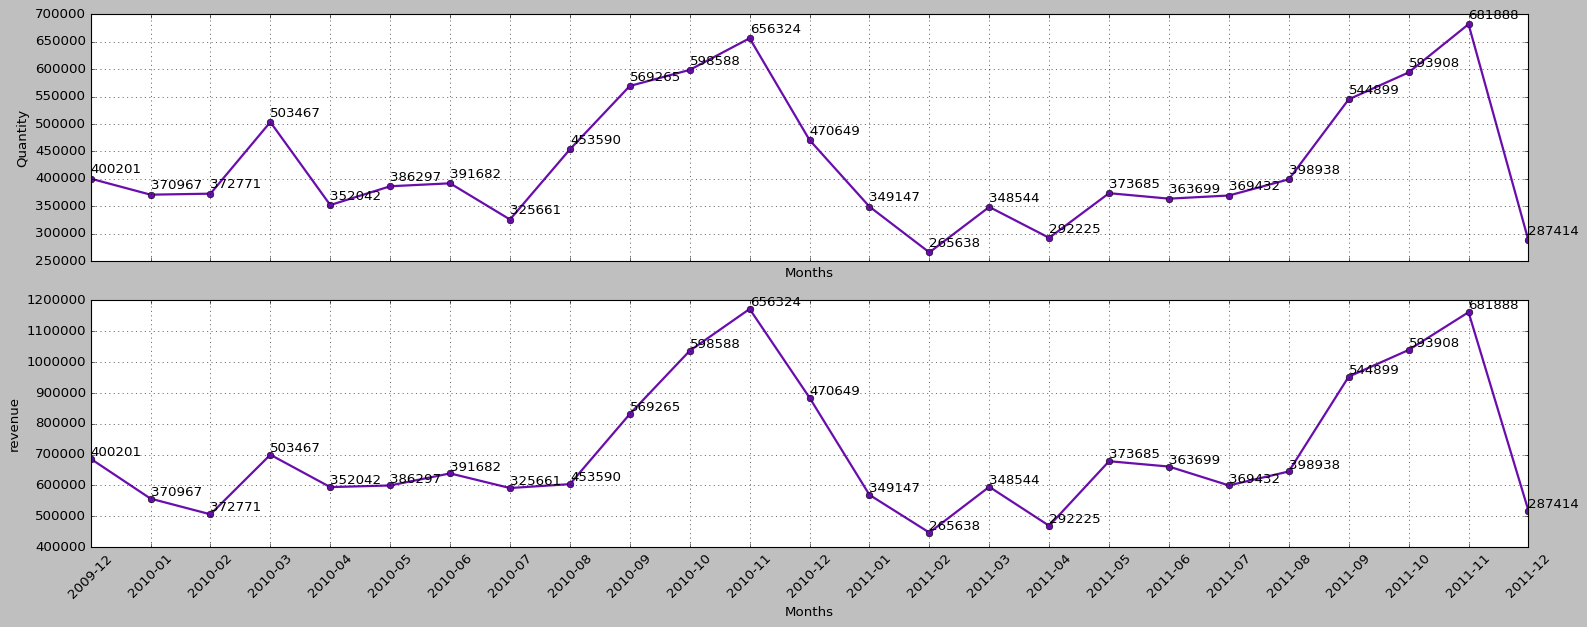

In [36]:
fig , ax = plt.subplots(2,1,figsize=(20,8), sharex=True)

ax[0].plot(monthly_quantity.index, monthly_quantity.values, color ='#6A0DAD', linewidth = 2, marker = "o" )
ax[0].set_xlabel("Months")
ax[0].set_ylabel("Quantity")
ax[0].grid(True)
for i in range(len(monthly_quantity.index)):
    ax[0].text(monthly_quantity.index[i], monthly_quantity.values[i]+10000, f"{monthly_quantity.values[i]}")


ax[1].plot(monthly_revenue.index, monthly_revenue.values, color ='#6A0DAD', linewidth = 2, marker = "o" )
ax[1].set_xlabel("Months")
ax[1].set_ylabel("revenue")
ax[1].grid(True)
for i in range(len(monthly_quantity.index)):
    ax[1].text(monthly_revenue.index[i], monthly_revenue.values[i]+10000, f"{monthly_quantity.values[i]}")

plt.xticks(rotation= 45)
plt.tight_layout()

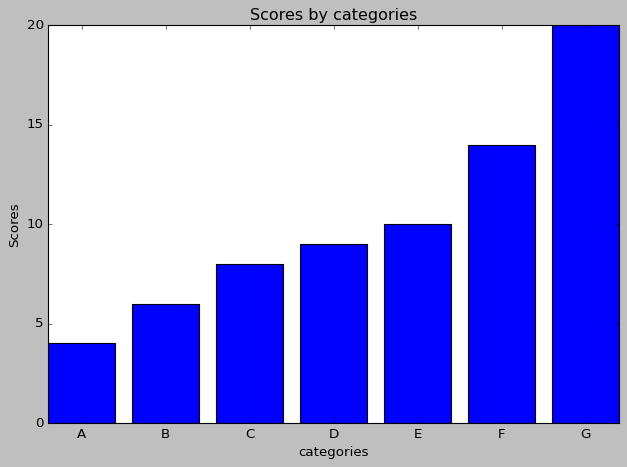

In [37]:

x = ["A", "B", "C", "D","E", "F","G"]
y = [4,6,8,9,10,14,20]

plt.bar(x, y)
plt.xlabel('categories')
plt.ylabel("Scores")
plt.title("Scores by categories")
plt.tight_layout()

In [38]:
import seaborn as sns

In [39]:
df.info()

<class 'pandas.DataFrame'>
Index: 805620 entries, 0 to 1067370
Data columns (total 10 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   Invoice      805620 non-null  object        
 1   StockCode    805620 non-null  object        
 2   Description  805620 non-null  object        
 3   Quantity     805620 non-null  int64         
 4   InvoiceDate  805620 non-null  datetime64[us]
 5   Price        805620 non-null  float64       
 6   Customer ID  805620 non-null  float64       
 7   Country      805620 non-null  str           
 8   Revenue      805620 non-null  float64       
 9   Month        805620 non-null  str           
dtypes: datetime64[us](1), float64(3), int64(1), object(3), str(2)
memory usage: 67.6+ MB


In [40]:
df_quantity = df[(df["Quantity"]>0) & (df["Quantity"]<100)]

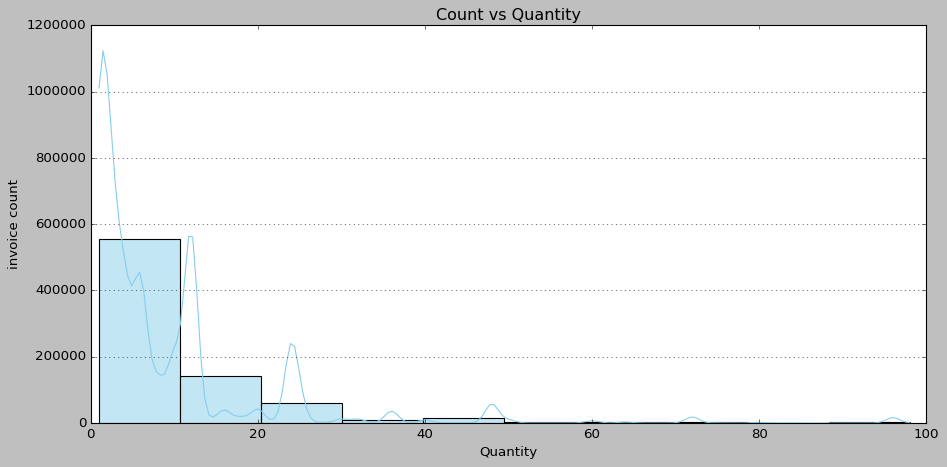

In [49]:
plt.figure(figsize=(12,6))
sns.histplot(df_quantity["Quantity"], bins=10, kde=True, color = "skyblue")
plt.xlabel("Quantity")
plt.ylabel("invoice count")
plt.title("Count vs Quantity")
plt.tight_layout()
plt.grid(axis="y")
plt.show()

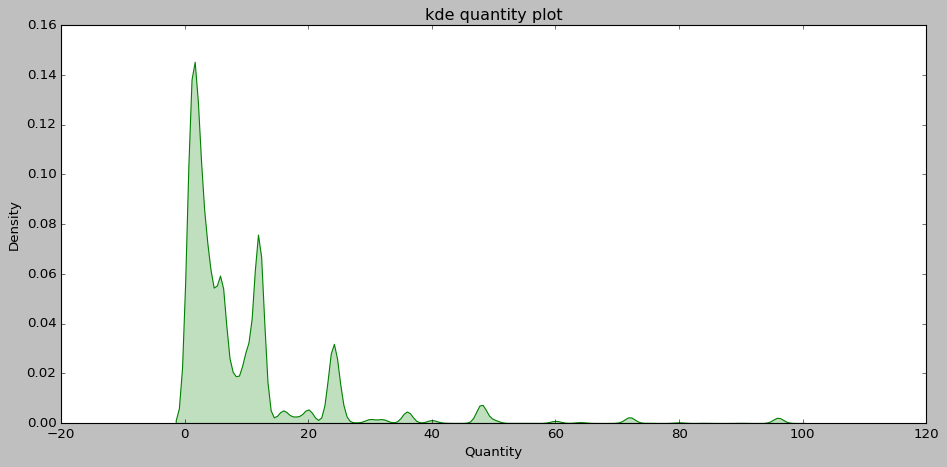

In [54]:
plt.figure(figsize=(12,6))
sns.kdeplot(df_quantity["Quantity"], fill= True, color="green")
plt.title("kde quantity plot")
plt.tight_layout()
plt.show()

In [55]:
df.info()

<class 'pandas.DataFrame'>
Index: 805620 entries, 0 to 1067370
Data columns (total 10 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   Invoice      805620 non-null  object        
 1   StockCode    805620 non-null  object        
 2   Description  805620 non-null  object        
 3   Quantity     805620 non-null  int64         
 4   InvoiceDate  805620 non-null  datetime64[us]
 5   Price        805620 non-null  float64       
 6   Customer ID  805620 non-null  float64       
 7   Country      805620 non-null  str           
 8   Revenue      805620 non-null  float64       
 9   Month        805620 non-null  str           
dtypes: datetime64[us](1), float64(3), int64(1), object(3), str(2)
memory usage: 67.6+ MB


In [ ]:
df_sample = df[["Quantity", "Price", "Revenue", "Country", "Month"]].copy()

In [57]:
df_sample

,Quantity,Price,Revenue,Country,Month
0,6,2.55,15.30,United Kingdom,2010-12
1,6,3.39,20.34,United Kingdom,2010-12
2,8,2.75,22.00,United Kingdom,2010-12
3,6,3.39,20.34,United Kingdom,2010-12
4,6,3.39,20.34,United Kingdom,2010-12
...,...,...,...,...,...
1067366,2,2.95,5.90,United Kingdom,2010-12
1067367,1,3.75,3.75,United Kingdom,2010-12
1067368,1,3.75,3.75,United Kingdom,2010-12
1067369,2,3.75,7.50,United Kingdom,2010-12


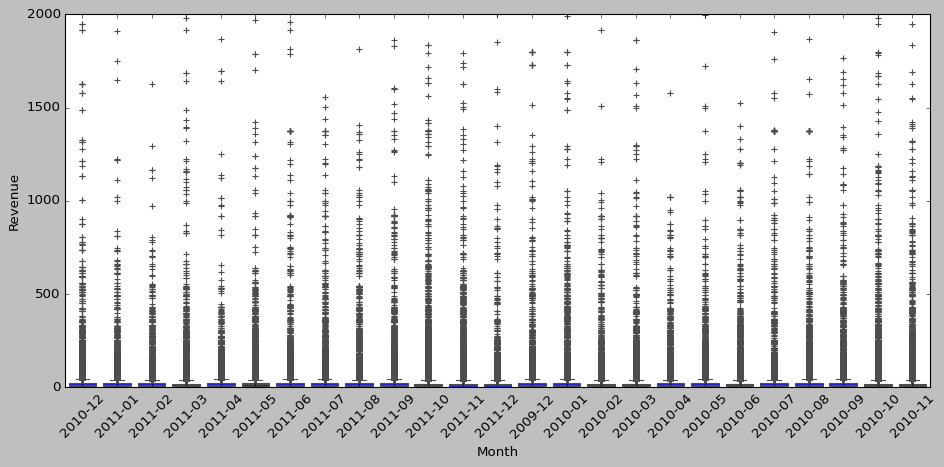

In [62]:
plt.figure(figsize = (12,6))
sns.boxplot(data = df_sample, x = "Month", y = "Revenue")
plt.xticks(rotation = 45)
plt.ylim(0,2000)
plt.tight_layout()
plt.show()

In [76]:
df_revenue_sample = df[(df["Revenue"]>1000) & (df["Revenue"]<2000)]

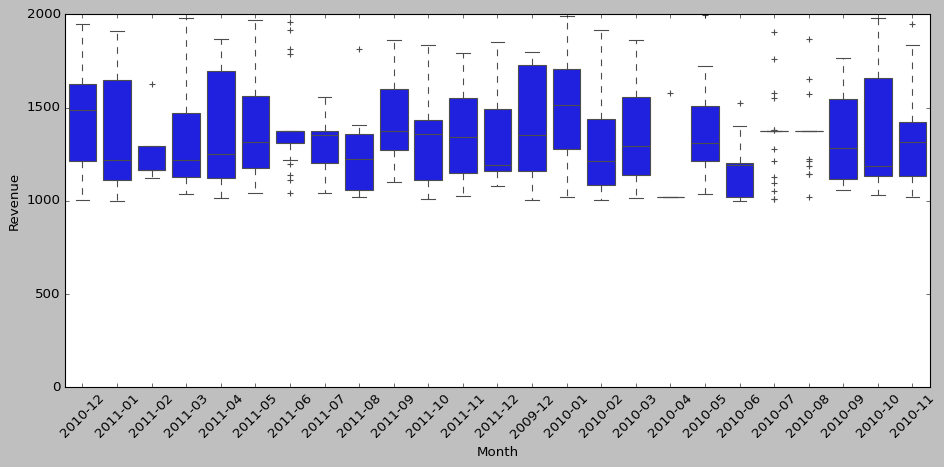

In [77]:
plt.figure(figsize = (12,6))
sns.boxplot(data = df_revenue_sample, x = "Month", y = "Revenue")
plt.xticks(rotation = 45)
plt.ylim(0,2000)
plt.tight_layout()
plt.show()

In [81]:
top_countries = df.groupby('Country')["Revenue"].sum().sort_values(ascending=False).head(10)

In [87]:
print(top_countries)


Country
United Kingdom    1.472315e+07
EIRE              6.216311e+05
Netherlands       5.542323e+05
Germany           4.312625e+05
France            3.552575e+05
Australia         1.699681e+05
Spain             1.091785e+05
Switzerland       1.003653e+05
Sweden            9.154972e+04
Denmark           6.986219e+04
Name: Revenue, dtype: float64


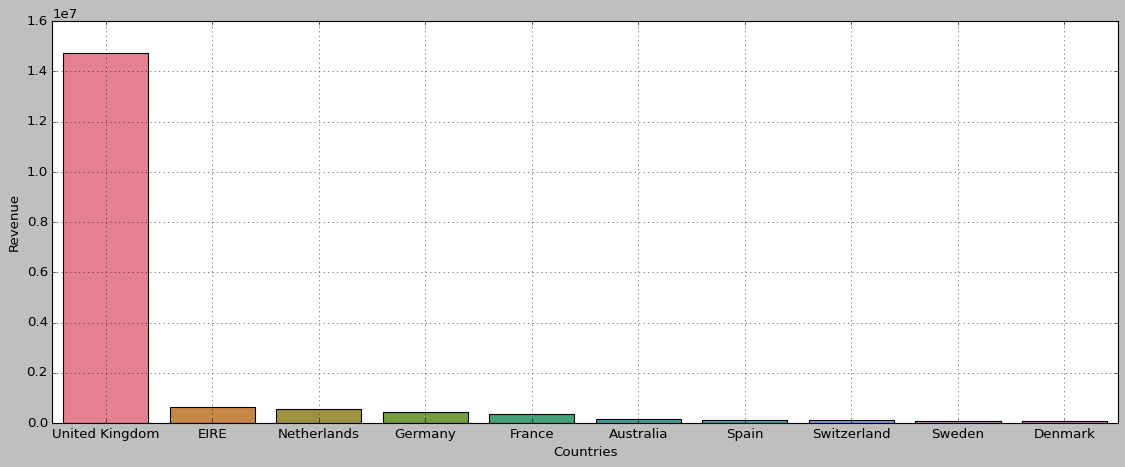

In [93]:
plt.figure(figsize=(14,6))
sns.barplot(x=top_countries.index, y = top_countries.values, hue=top_countries.index)
plt.tight_layout()
plt.grid(True)
plt.xlabel("Countries")
plt.ylabel("Revenue")
plt.show()

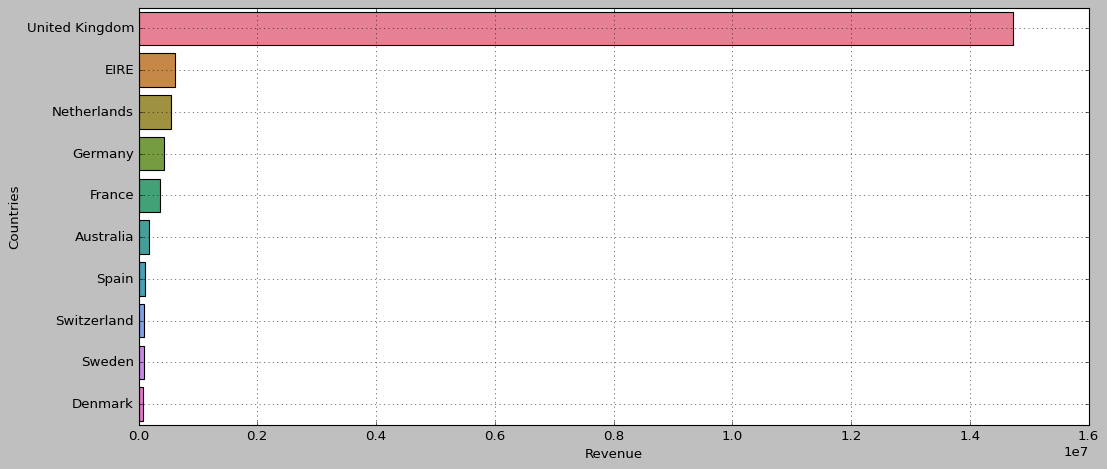

In [95]:
plt.figure(figsize=(14,6))
sns.barplot(x=top_countries.values, y = top_countries.index, hue=top_countries.index)
plt.tight_layout()
plt.grid(True)
plt.xlabel("Revenue")
plt.ylabel("Countries")
plt.show()